# train.csv -> EDA

In [1]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv('train.csv')

df.head(5)

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)
0,201801상순,건고추,화건,30 kg,상품,381666.666667,590000.0
1,201801중순,건고추,화건,30 kg,상품,380809.666667,590000.0
2,201801하순,건고추,화건,30 kg,상품,380000.000000,590000.0
3,201802상순,건고추,화건,30 kg,상품,380000.000000,590000.0
4,201802중순,건고추,화건,30 kg,상품,376666.666667,590000.0


In [2]:
df.columns

Index(['시점', '품목명', '품종명', '거래단위', '등급', '평년 평균가격(원)', '평균가격(원)'], dtype='object')

In [3]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['axes.unicode_minus'] = False

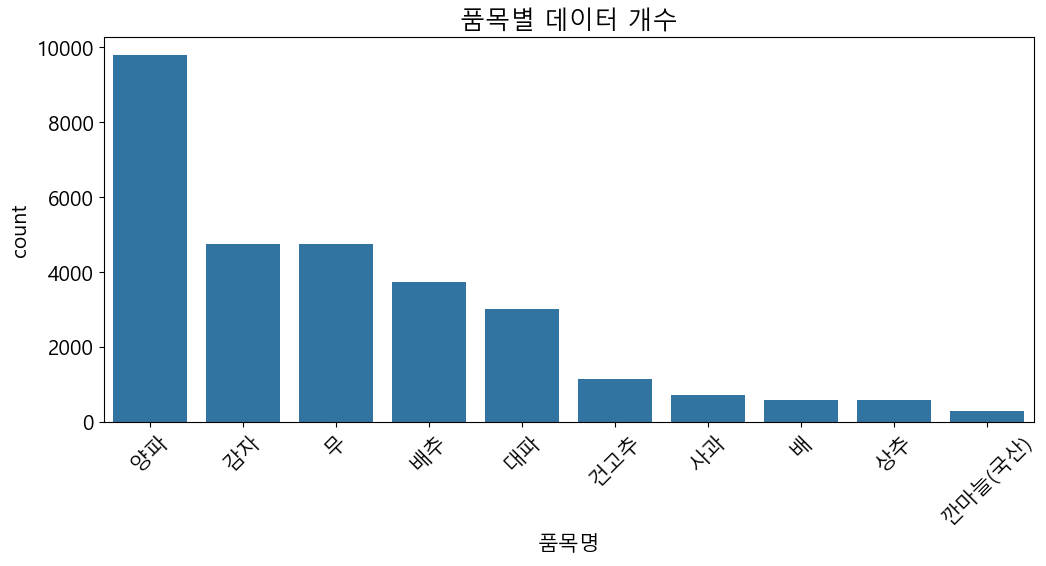

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
# df['품목명']을 그대로 사용합니다.
sns.countplot(data=df, x='품목명', order=df['품목명'].value_counts().index)

plt.title('품목별 데이터 개수')
plt.xticks(rotation=45) # 글자가 겹치지 않게 회전
plt.show()

양파가 압도적으로 많고, 깐마늘이나 배 데이터가 상대적으로 적음
모델 학습 시 데이터가 많은 양파는 예측 정확도 높을 수 있지만, 데이터 적은 품목은 '과적합'위험 -> 보완필요

### '거래단위'가 가격에 주는 영향 확인 (예: 배추)

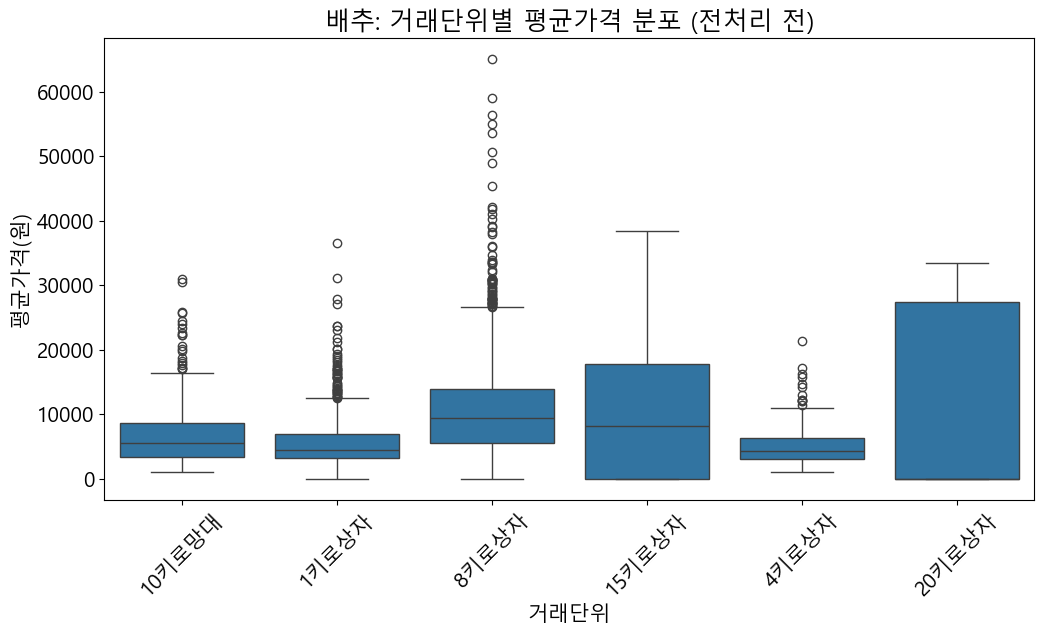

In [9]:
import seaborn as sns

# '배추' 데이터만 필터링
baechu_df = df[df['품목명'] == '배추']

plt.figure(figsize=(12, 6))
sns.boxplot(data=baechu_df, x='거래단위', y='평균가격(원)')
plt.title('배추: 거래단위별 평균가격 분포 (전처리 전)')
plt.xticks(rotation=45)
plt.show()

단위마다 가격편차가 크니, 모든 품목을 1KG당 가격으로 환산(단위통일) 필요

# 무게 단위 정규화

In [12]:
import re

def get_kg(unit):
    # 1. 숫자가 포함되어 있으면 추출 (예: '20키로상자' -> 20)
    numbers = re.findall(r'\d+', unit)
    if not numbers:
        return 1.0 # 숫자가 없으면 일단 1로 처리
    
    amount = float(numbers[0])
    
    # 2. 단위가 'g'인 경우 kg으로 환산 (예: '100 g' -> 0.1)
    if 'g' in unit.lower() and 'kg' not in unit.lower():
        return amount / 1000.0
    
    # 3. '톤' 단위 처리 (예: '5톤트럭' -> 5000)
    if '톤' in unit:
        return amount * 1000.0
    
    return amount

# 새로운 '무게(kg)' 컬럼 생성
df['무게(kg)'] = df['거래단위'].apply(get_kg)

# 1kg당 가격 계산
df['가격_per_kg'] = df['평균가격(원)'] / df['무게(kg)']

# 결과 확인
print(df[['거래단위', '무게(kg)', '평균가격(원)', '가격_per_kg']].head())

    거래단위  무게(kg)   평균가격(원)     가격_per_kg
0  30 kg    30.0  590000.0  19666.666667
1  30 kg    30.0  590000.0  19666.666667
2  30 kg    30.0  590000.0  19666.666667
3  30 kg    30.0  590000.0  19666.666667
4  30 kg    30.0  590000.0  19666.666667


In [13]:
# 앞의 10개 행만, 전처리 관련 컬럼들만 확인
display(df[['거래단위', '무게(kg)', '평균가격(원)', '가격_per_kg']].head(10))

,거래단위,무게(kg),평균가격(원),가격_per_kg
0,30 kg,30.0,590000.0,19666.666667
1,30 kg,30.0,590000.0,19666.666667
2,30 kg,30.0,590000.0,19666.666667
3,30 kg,30.0,590000.0,19666.666667
4,30 kg,30.0,590000.0,19666.666667
5,30 kg,30.0,580833.0,19361.100000
6,30 kg,30.0,563333.0,18777.766667
7,30 kg,30.0,575000.0,19166.666667
8,30 kg,30.0,575000.0,19166.666667
9,30 kg,30.0,575000.0,19166.666667


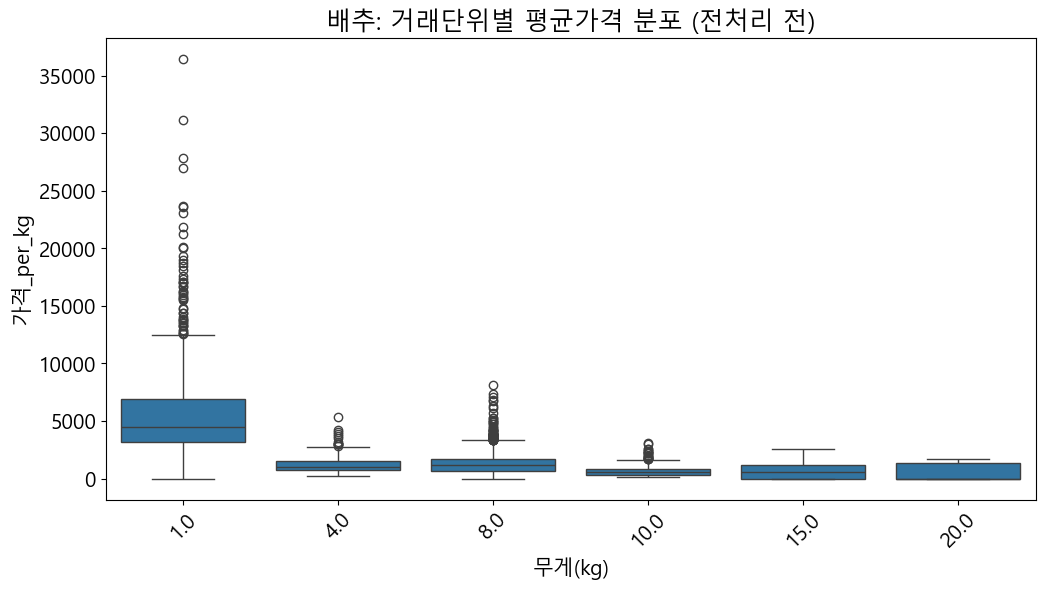

In [17]:
import seaborn as sns

# '배추' 데이터만 필터링
baechu_df = df[df['품목명'] == '배추']

plt.figure(figsize=(12, 6))
sns.boxplot(data=baechu_df, x='무게(kg)', y='가격_per_kg')
plt.title('배추: 거래단위별 평균가격 분포 (전처리 전)')
plt.xticks(rotation=45)
plt.show()

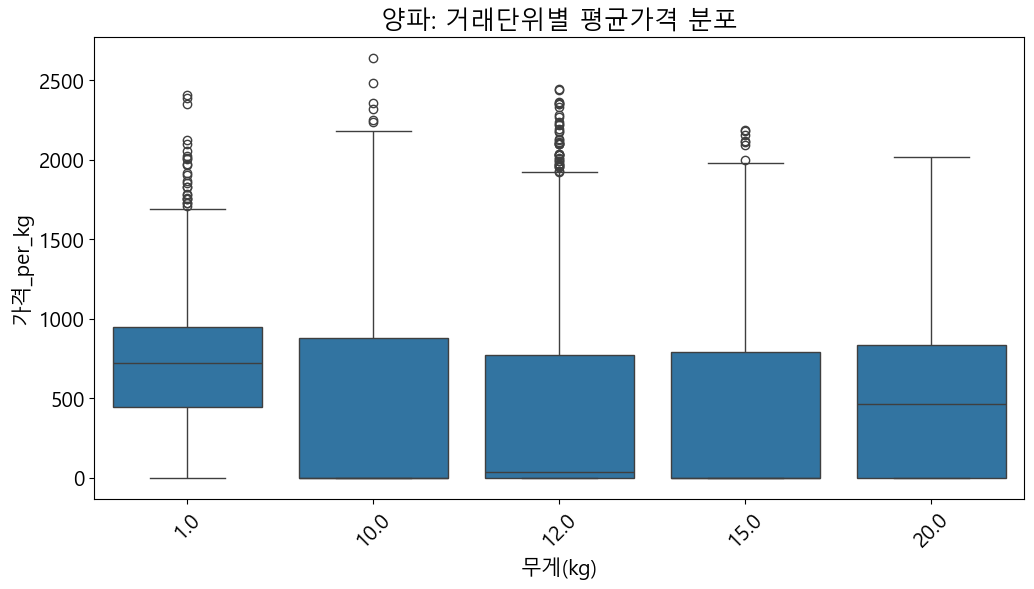

In [18]:
# '양파' 데이터만 필터링
onion_df = df[df['품목명'] == '양파']

plt.figure(figsize=(12, 6))
sns.boxplot(data=onion_df, x='무게(kg)', y='가격_per_kg')
plt.title('양파: 거래단위별 평균가격 분포')
plt.xticks(rotation=45)
plt.show()

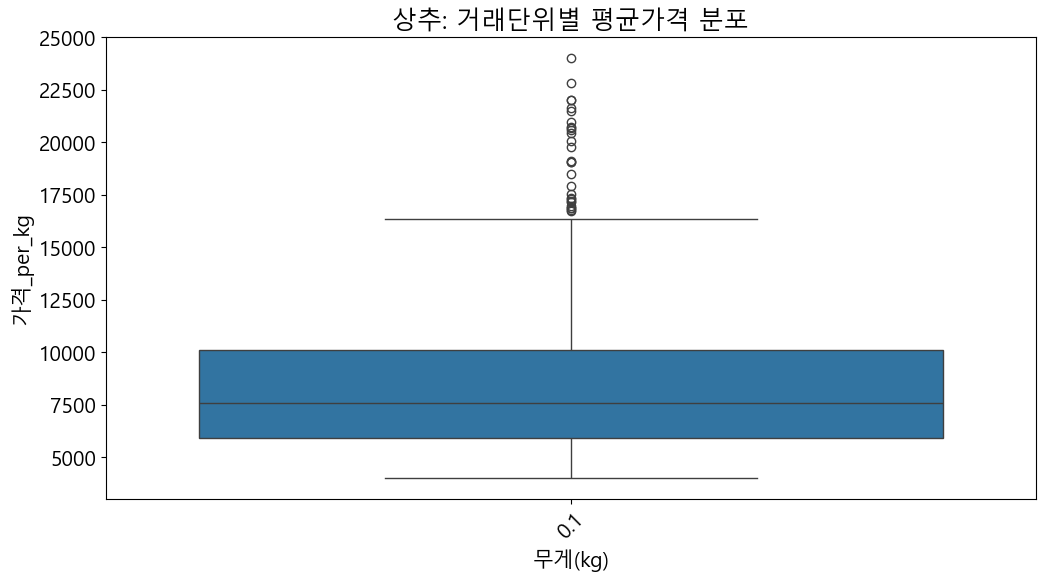

In [19]:
# '상추' 데이터만 필터링
lettuce_df = df[df['품목명'] == '상추']

plt.figure(figsize=(12, 6))
sns.boxplot(data=lettuce_df, x='무게(kg)', y='가격_per_kg')
plt.title('상추: 거래단위별 평균가격 분포')
plt.xticks(rotation=45)
plt.show()

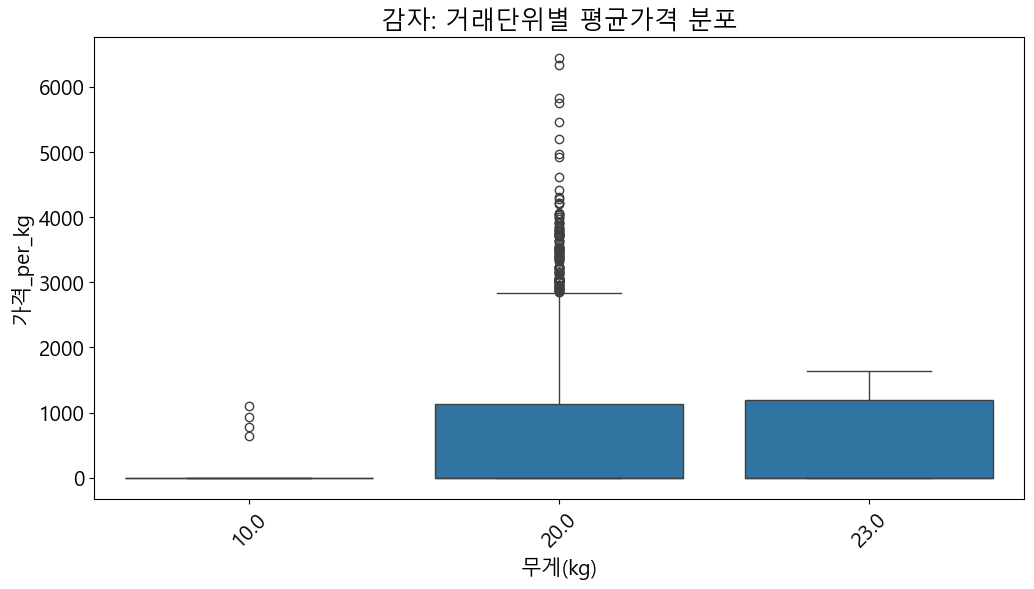

In [21]:
# '감자' 데이터만 필터링
potato_df = df[df['품목명'] == '감자']

plt.figure(figsize=(12, 6))
sns.boxplot(data=potato_df, x='무게(kg)', y='가격_per_kg')
plt.title('감자: 거래단위별 평균가격 분포')
plt.xticks(rotation=45)
plt.show()

In [6]:
# 시점 컬럼에서 연도, 월, 순 추출하기
df['연도'] = df['시점'].str[:4].astype(int)
df['월'] = df['시점'].str[4:6].astype(int)
df['순'] = df['시점'].str[6:]

# 제대로 쪼개졌는지 확인
print(df[['시점', '연도', '월', '순']].head())

         시점    연도  월   순
0  201801상순  2018  1  상순
1  201801중순  2018  1  중순
2  201801하순  2018  1  하순
3  201802상순  2018  2  상순
4  201802중순  2018  2  중순


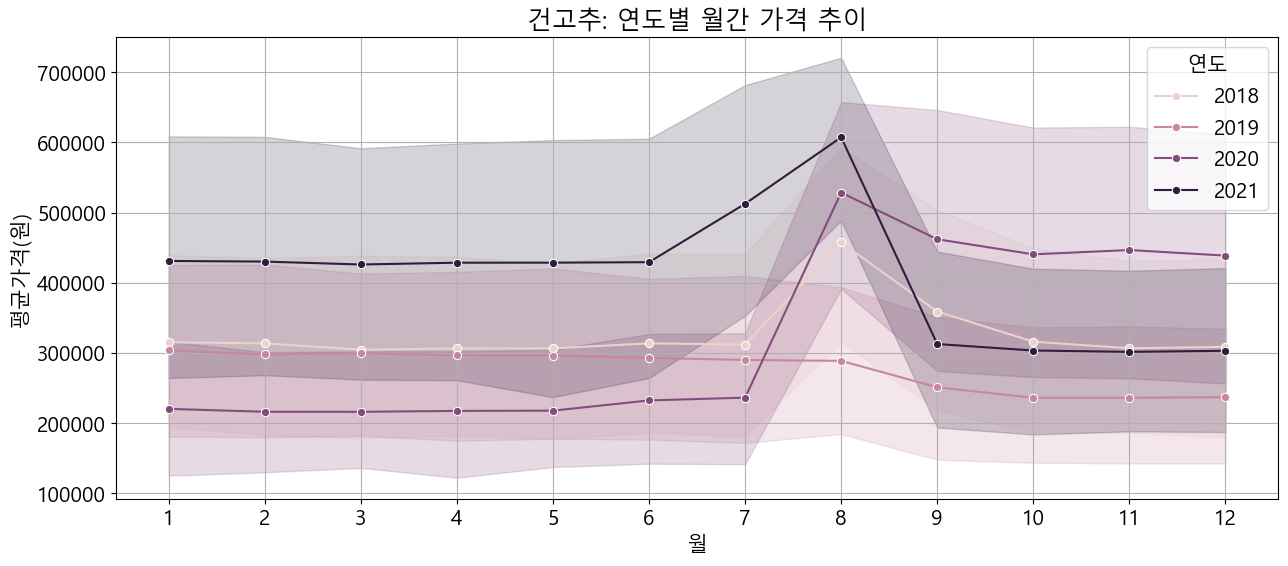

In [7]:
# 건고추 품목의 월별 가격 변화 (연도별 비교)
chili_df = df[df['품목명'] == '건고추']

plt.figure(figsize=(15, 6))
sns.lineplot(data=chili_df, x='월', y='평균가격(원)', hue='연도', marker='o')
plt.title('건고추: 연도별 월간 가격 추이')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

8월에 가격이 급등했다 9월에 다시 떨어지는 공통적인 패턴 -> 월 정보 중요
21년도에 예년보다 가격 변동폭이 훨씬 컸음

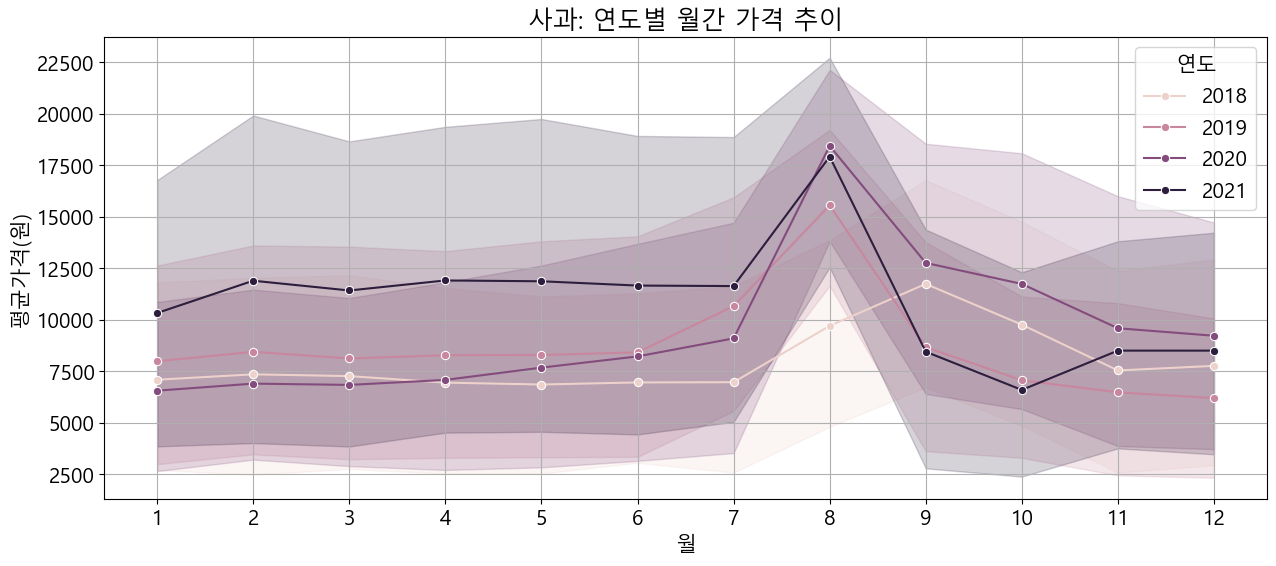

In [22]:
# 건고추 품목의 월별 가격 변화 (연도별 비교)
apple_df = df[df['품목명'] == '사과']

plt.figure(figsize=(15, 6))
sns.lineplot(data=apple_df, x='월', y='평균가격(원)', hue='연도', marker='o')
plt.title('사과: 연도별 월간 가격 추이')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

### 시기별 가격

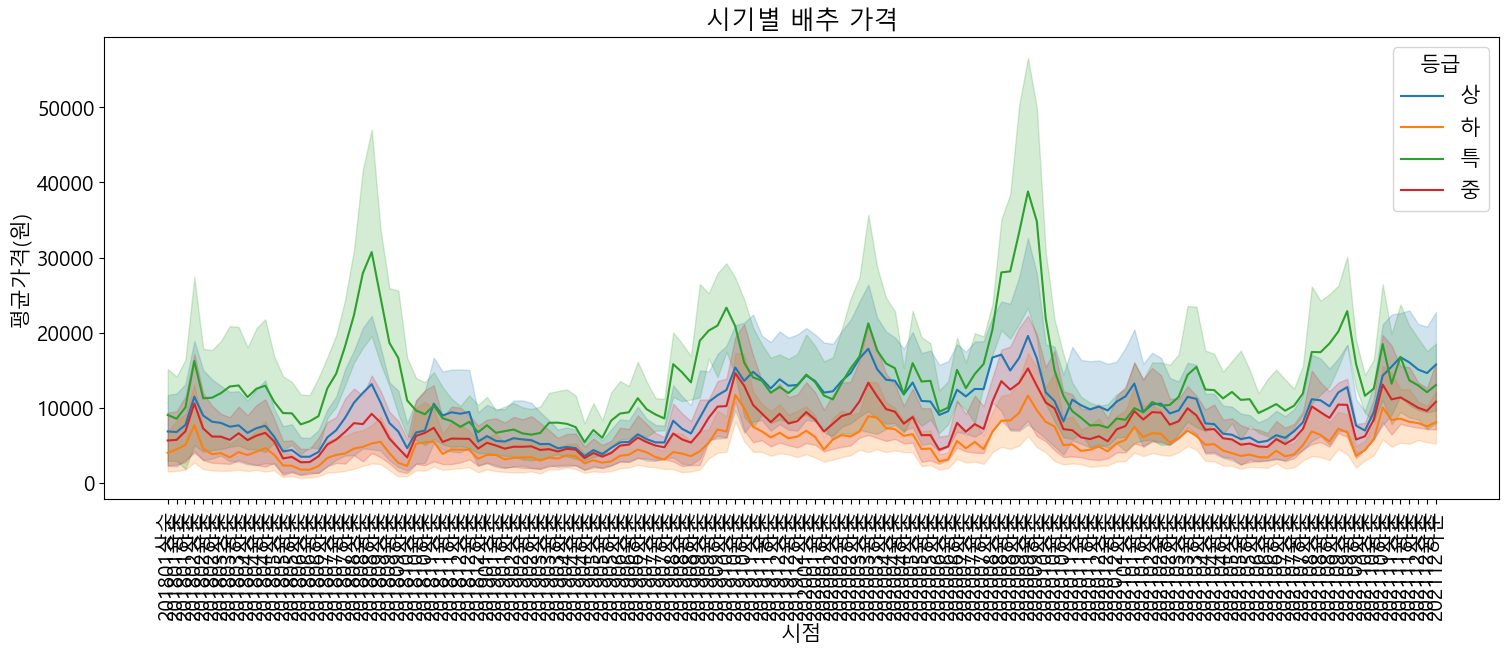

In [24]:
# 연도별/순별 가격 흐름 (대표 품목 하나 선정)
# '시점' 컬럼에서 연도만 추출
df['Year'] = df['시점'].str[:4]

plt.figure(figsize=(18, 6))
sns.lineplot(data=df[df['품목명'] == '배추'], x='시점', y='평균가격(원)', hue='등급')
plt.xticks(rotation=90) # 시점이 많으니 글자를 세로로
plt.title('시기별 배추 가격')
plt.show()

특 > 상 > 중 > 하 순으로 등락이 심함 

### 연도별-월별 흐름

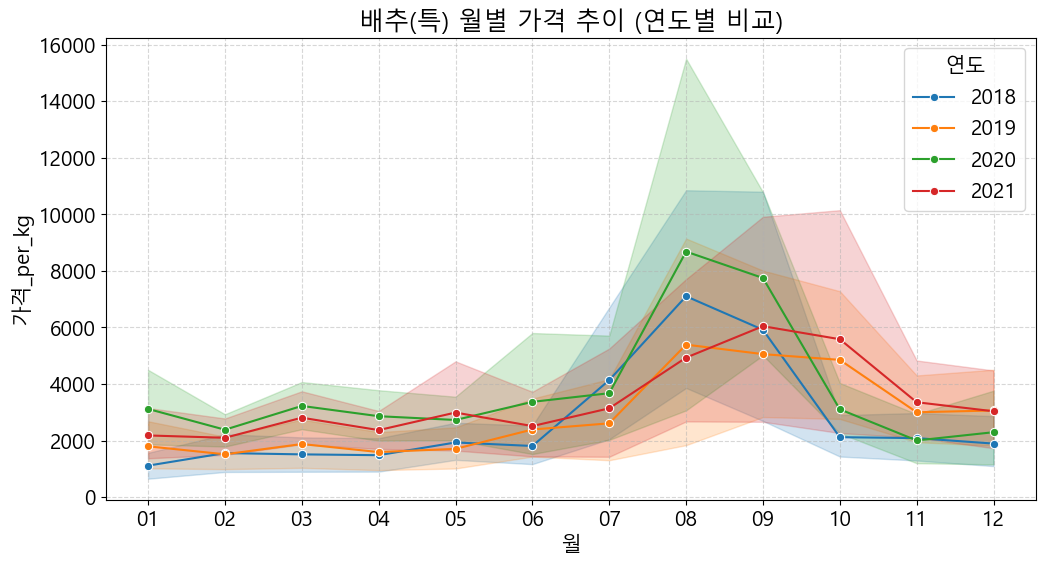

In [25]:
# 전처리: 연도, 월, 순 분리 (안 하셨다면 실행)
df['연도'] = df['시점'].str[:4]
df['월'] = df['시점'].str[4:6]
df['순'] = df['시점'].str[6:]

plt.figure(figsize=(12, 6))
# 배추 데이터 중 '특' 등급만 골라서 보면 흐름이 더 깔끔합니다.
target_df = df[(df['품목명'] == '배추') & (df['등급'] == '특')]

sns.lineplot(data=target_df, x='월', y='가격_per_kg', hue='연도', marker='o')
plt.title('배추(특) 월별 가격 추이 (연도별 비교)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 상순-중순-하순 특징 비교

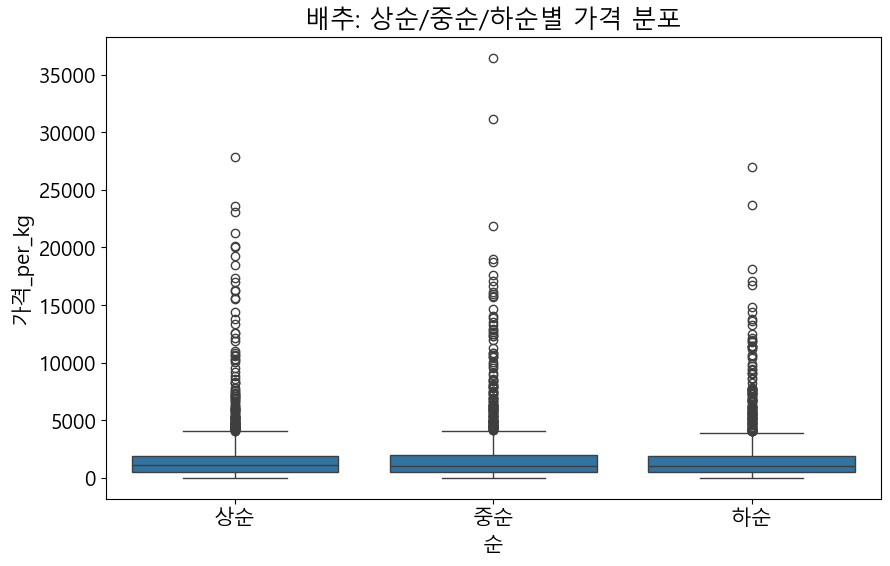

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['품목명'] == '배추'], x='순', y='가격_per_kg', order=['상순', '중순', '하순'])
plt.title('배추: 상순/중순/하순별 가격 분포')
plt.show()

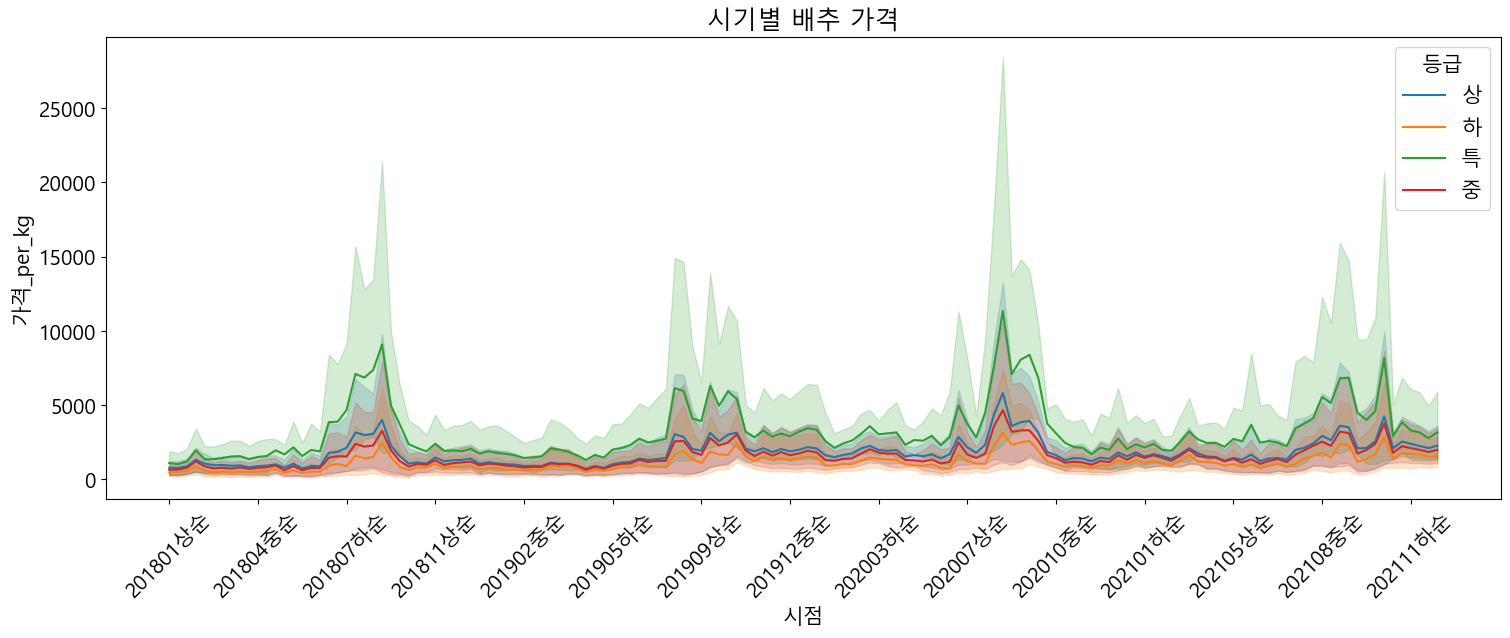

In [28]:
plt.figure(figsize=(18, 6))
ax = sns.lineplot(data=df[df['품목명'] == '배추'], x='시점', y='가격_per_kg', hue='등급')

# X축 눈금을 10개 간격으로 표시
xticks = ax.get_xticks()
ax.set_xticks(xticks[::10]) 

plt.xticks(rotation=45)
plt.title('시기별 배추 가격')
plt.show()

# 2. TRAIN_산지공판장_2018-2021.csv  & TRAIN_전국도매_2018-2021.csv

In [32]:
df_os = pd.read_csv('TRAIN_산지공판장_2018-2021.csv')  #df_os <- onsite 산지공판장이라는 뜻
df_os.head()

,시점,공판장코드,공판장명,품목코드,품목명,품종코드,품종명,등급코드,등급명,총반입량(kg),...,평균가(원/kg),중간가(원/kg),최저가(원/kg),최고가(원/kg),경매 건수,전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,연도
0,201801상순,1000000000,*전국농협공판장,501,감자,50101,수미,11,특,15470.0,...,1712.637363,1723.961039,1545.454545,2320.666667,7,1947.350427,1769.858320,1023.982379,0.0,2018
1,201801상순,1000000000,*전국농협공판장,501,감자,50101,수미,12,상,2900.0,...,1198.655172,1252.737207,893.055556,1417.857143,4,1301.239669,1348.253676,571.311475,0.0,2018
2,201801상순,1000000000,*전국농협공판장,501,감자,50199,기타감자,13,보통,1320.0,...,615.000000,600.000000,240.000000,911.875000,7,630.851064,449.166667,473.032787,0.0,2018
3,201801상순,1000000000,*전국농협공판장,501,감자,50199,기타감자,12,상,460.0,...,544.130435,365.000000,200.000000,1650.000000,5,1088.046875,1129.600000,734.024390,0.0,2018
4,201801상순,1000000000,*전국농협공판장,501,감자,50199,기타감자,11,특,30967.0,...,1876.454484,2010.440477,1598.327715,2438.720588,8,2126.402457,1779.262728,1750.544700,0.0,2018


In [34]:
df_os.columns

Index(['시점', '공판장코드', '공판장명', '품목코드', '품목명', '품종코드', '품종명', '등급코드', '등급명',
       '총반입량(kg)', '총거래금액(원)', '평균가(원/kg)', '중간가(원/kg)', '최저가(원/kg)',
       '최고가(원/kg)', '경매 건수', '전순 평균가격(원) PreVious SOON',
       '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR',
       '평년 평균가격(원) Common Year SOON', '연도'],
      dtype='object')

In [41]:
df_ws = pd.read_csv('TRAIN_전국도매_2018-2021.csv')  #df_ws은 wholoesale 도매라는 뜻
df_ws.head(10)

,시점,시장코드,시장명,품목코드,품목명,품종코드,품종명,총반입량(kg),총거래금액(원),평균가(원/kg),...,저가(20%) 평균가,중간가(원/kg),최저가(원/kg),최고가(원/kg),경매 건수,전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,연도
0,201801상순,100000,*전국도매시장,501,감자,50124,깐감자,20.0,86520,4326.000000,...,4326.000000,4326.000000,4326.000000,4326.000000,1,0.000000,4009.000000,0.000000,0.000000,2018
1,201801상순,100000,*전국도매시장,501,감자,50121,돼지감자,12380.0,11650810,941.099354,...,545.105717,1010.000000,200.000000,3000.000000,117,11213.358450,9174.196723,8167.895632,0.000000,2018
2,201801상순,100000,*전국도매시장,501,감자,50110,자주감자,240.0,158400,660.000000,...,500.000000,550.000000,500.000000,1000.000000,7,12553.279352,12612.216445,24990.324897,18483.961304,2018
3,201801상순,100000,*전국도매시장,501,감자,50111,가을감자,10.0,37500,3750.000000,...,3700.000000,3750.000000,3700.000000,3800.000000,2,24929.463415,40365.081269,0.000000,0.000000,2018
4,201801상순,100000,*전국도매시장,501,감자,50199,기타감자,1367301.3,2403199462,1757.622451,...,955.289668,1360.453431,0.000000,10581.081081,872,30806.779529,27661.150770,23741.953223,19340.121989,2018
5,201801상순,100000,*전국도매시장,501,감자,50114,봄감자,4400.0,5945000,1351.136364,...,927.537313,1467.256637,890.000000,2011.294118,4,32192.960000,12237.500000,21368.157248,0.000000,2018
6,201801상순,100000,*전국도매시장,501,감자,50105,조풍,11946.0,25474000,2132.429265,...,1629.741379,2199.579832,651.470588,10250.000000,7,42937.510717,39021.512648,7116.245364,0.000000,2018
7,201801상순,100000,*전국도매시장,501,감자,50103,대지,1021396.0,1848615100,1809.890679,...,897.194232,1000.000000,0.000000,3850.000000,381,30162.092090,29290.725597,31462.782438,21615.064179,2018
8,201801상순,100000,*전국도매시장,501,감자,50101,수미,2423696.5,4135898623,1706.442462,...,867.893389,1261.000000,0.000000,9859.633333,1229,168039.623201,27204.818622,22433.563798,18536.038912,2018
9,201801상순,100000,*전국도매시장,501,감자,50115,조림감자,1600.0,744000,465.000000,...,316.666667,421.428571,300.000000,1150.000000,13,9115.853659,8313.253012,17910.714286,8007.219878,2018


In [37]:
df_ws.columns

Index(['시점', '시장코드', '시장명', '품목코드', '품목명', '품종코드', '품종명', '총반입량(kg)',
       '총거래금액(원)', '평균가(원/kg)', '고가(20%) 평균가', '중가(60%) 평균가 ', '저가(20%) 평균가',
       '중간가(원/kg)', '최저가(원/kg)', '최고가(원/kg)', '경매 건수',
       '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth',
       '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON', '연도'],
      dtype='object')

### 감자를 기준으로 도매가(df_ws)가 오르면 소매가(df)도 오르는 지 확인

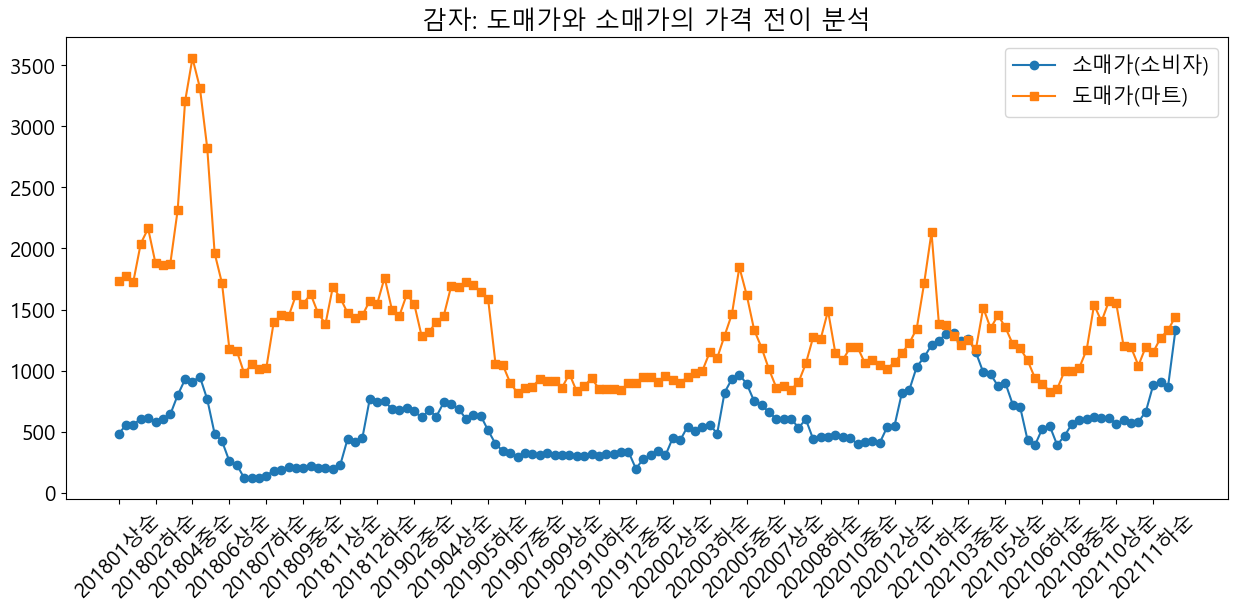

In [40]:
# 1. 소매가 데이터에서 감자만 추출 (단위 정규화된 가격 사용)
potato_retail = df[df['품목명'] == '감자'].groupby('시점')['가격_per_kg'].mean().reset_index()

# 2. 도매가 데이터에서 감자만 추출
potato_wholesale = df_ws[df_ws['품목코드'] == 501].groupby('시점')['평균가(원/kg)'].mean().reset_index()

# 3. 두 데이터 병합
potato_merge = pd.merge(potato_retail, potato_wholesale, on='시점', how='inner')
potato_merge.columns = ['시점', '소매가_1kg', '도매가_1kg']

# 4. 시각화: 도매가와 소매가의 흐름 비교
plt.figure(figsize=(15, 6))
plt.plot(potato_merge['시점'], potato_merge['소매가_1kg'], label='소매가(소비자)', marker='o')
plt.plot(potato_merge['시점'], potato_merge['도매가_1kg'], label='도매가(마트)', marker='s')
plt.title('감자: 도매가와 소매가의 가격 전이 분석')
plt.legend()
plt.xticks(rotation=45)
# 눈금 조절 (아까 배운 팁!)
plt.gca().set_xticks(plt.gca().get_xticks()[::5])
plt.show()

도매가 > 소매가

### 도매가, 소매가 단위 확인

In [47]:
# 1. 소매가(df) 데이터 정리 (1kg 단가 기준 평균)
retail_avg = df.groupby(['시점', '품목명'])['가격_per_kg'].mean().reset_index()

# 2. 도매가(df_ws) 데이터 정리 (1kg 단가 기준 평균)
wholesale_avg = df_ws.groupby(['시점', '품목명'])['평균가(원/kg)'].mean().reset_index()

# 3. 데이터 합치기 (이게 바로 price_analysis 입니다!)
price_analysis = pd.merge(retail_avg, wholesale_avg, on=['시점', '품목명'], how='inner')
price_analysis.columns = ['시점', '품목명', '소매가_kg', '도매가_kg']

# 4. 품목별 평균 비교 및 역전현상 체크
price_comparison = price_analysis.groupby('품목명')[['소매가_kg', '도매가_kg']].mean()
price_comparison['차이(소매-도매)'] = price_comparison['소매가_kg'] - price_comparison['도매가_kg']
price_comparison['역전현상(도매가 더 비쌈)'] = price_comparison['차이(소매-도매)'] < 0

# 5. 결과 출력
print("--- 품목별 소매 vs 도매 가격 비교 (1kg 기준) ---")
display(price_comparison.sort_values(by='차이(소매-도매)'))

--- 품목별 소매 vs 도매 가격 비교 (1kg 기준) ---


,소매가_kg,도매가_kg,차이(소매-도매),역전현상(도매가 더 비쌈)
품목명,,,,
사과,927.117153,2812.598790,-1885.481637,True
무,402.228929,1645.301169,-1243.072240,True
감자,568.084871,1328.452560,-760.367689,True
배,1674.269792,2306.335010,-632.065219,True
양파,474.003328,819.660132,-345.656804,True
배추,1773.563139,1140.697551,632.865587,False
대파,2521.874556,1569.737312,952.137243,False
상추,8679.218750,3166.833370,5512.385380,False


In [48]:
# 소매 데이터에서 사과 아무거나 한 줄 출력
print("--- 소매 사과 데이터 샘플 ---")
display(df[df['품목명'] == '사과'].head(1))

# 도매 데이터에서 사과 아무거나 한 줄 출력
print("\n--- 도매 사과 데이터 샘플 ---")
display(df_ws[df_ws['품목명'] == '사과'].head(1))

--- 소매 사과 데이터 샘플 ---


,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원),연도,월,순,Year,무게(kg),가격_per_kg
1152,201801상순,사과,후지,10 개,상품,21461.666667,20361.0,2018,01,상순,2018,10.0,2036.1



--- 도매 사과 데이터 샘플 ---


,시점,시장코드,시장명,품목코드,품목명,품종코드,품종명,총반입량(kg),총거래금액(원),평균가(원/kg),...,저가(20%) 평균가,중간가(원/kg),최저가(원/kg),최고가(원/kg),경매 건수,전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,연도
13,201801상순,100000,*전국도매시장,601,사과,60145,로얄부사,287565.0,634601200,2206.809591,...,1320.895904,1987.356322,0.0,4901.459854,239,23366.814482,20880.566279,21662.294413,34852.123851,2018


In [49]:
def get_kg_updated(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    item = row['품목명']
    
    # 1. 숫자 추출
    import re
    num_match = re.search(r'(\d+\.?\d*)', unit)
    num = float(num_match.group(1)) if num_match else 1.0
    
    # 2. 품목별 개당 무게 보정 (사과, 배, 무 등)
    if '개' in unit or '과' in unit:
        if item == '사과': return price / (num * 0.3)
        if item == '배': return price / (num * 0.6)
        if item == '무': return price / (num * 1.5)
        # 그 외 품목은 일단 개당 0.5kg 가정
        return price / (num * 0.5)
    
    # 3. kg, g 단위 처리
    if 'kg' in unit: return price / num
    if 'g' in unit: return price / (num / 1000)
    
    return price / num # 기본값

# 소매 데이터 재계산
df['가격_per_kg'] = df.apply(get_kg_updated, axis=1)

# 아까 만든 비교 코드 다시 돌려보기 (병합부터 다시!)
retail_avg = df.groupby(['시점', '품목명'])['가격_per_kg'].mean().reset_index()
wholesale_avg = df_ws.groupby(['시점', '품목명'])['평균가(원/kg)'].mean().reset_index()
price_analysis = pd.merge(retail_avg, wholesale_avg, on=['시점', '품목명'], how='inner')
price_analysis.columns = ['시점', '품목명', '소매가_kg', '도매가_kg']

# 결과 상위 5개 확인
print(price_analysis[price_analysis['품목명'] == '사과'].head())

          시점 품목명       소매가_kg       도매가_kg
5   201801상순  사과  2353.733333  2115.031907
13  201801중순  사과  2346.133333  2127.446389
21  201801하순  사과  2393.200000  2218.661009
29  201802상순  사과  2405.333333  2949.840092
37  201802중순  사과  2498.400000  2647.560057


In [50]:
# 1. 소매가(df) 데이터 정리 (1kg 단가 기준 평균)
retail_avg = df.groupby(['시점', '품목명'])['가격_per_kg'].mean().reset_index()

# 2. 도매가(df_ws) 데이터 정리 (1kg 단가 기준 평균)
wholesale_avg = df_ws.groupby(['시점', '품목명'])['평균가(원/kg)'].mean().reset_index()

# 3. 데이터 합치기 (이게 바로 price_analysis 입니다!)
price_analysis = pd.merge(retail_avg, wholesale_avg, on=['시점', '품목명'], how='inner')
price_analysis.columns = ['시점', '품목명', '소매가_kg', '도매가_kg']

# 4. 품목별 평균 비교 및 역전현상 체크
price_comparison = price_analysis.groupby('품목명')[['소매가_kg', '도매가_kg']].mean()
price_comparison['차이(소매-도매)'] = price_comparison['소매가_kg'] - price_comparison['도매가_kg']
price_comparison['역전현상(도매가 더 비쌈)'] = price_comparison['차이(소매-도매)'] < 0

# 5. 결과 출력
print("--- 품목별 소매 vs 도매 가격 비교 (1kg 기준) ---")
display(price_comparison.sort_values(by='차이(소매-도매)'))

--- 품목별 소매 vs 도매 가격 비교 (1kg 기준) ---


,소매가_kg,도매가_kg,차이(소매-도매),역전현상(도매가 더 비쌈)
품목명,,,,
감자,568.084871,1328.452560,-760.367689,True
양파,474.003328,819.660132,-345.656804,True
사과,3090.390509,2812.598790,277.791719,False
배,2790.449653,2306.335010,484.114642,False
배추,1773.563139,1140.697551,632.865587,False
대파,2521.874556,1569.737312,952.137243,False
상추,8679.218750,3166.833370,5512.385380,False
무,33582.912566,1645.301169,31937.611397,False


In [51]:
def get_kg_final(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    item = row['품목명']
    
    import re
    num_match = re.search(r'(\d+\.?\d*)', unit)
    num = float(num_match.group(1)) if num_match else 1.0
    
    # 품목별 정밀 보정 로직
    if '개' in unit or '망' in unit or '봉' in unit:
        if item == '사과': return price / (num * 0.3)
        if item == '배': return price / (num * 0.6)
        if item == '무': return price / (num * 1.5)
        # 양파 1망은 보통 1.5kg~3kg 사이입니다. 여기선 1.5kg으로 보정 시도
        if item == '양파': return price / (num * 1.5) 
        # 감자 한 봉지는 보통 1kg 정도지만, 더 높게 잡혀있을 가능성 확인
        if item == '감자': return price / (num * 1.0)
        return price / (num * 0.5)
    
    if 'kg' in unit: return price / num
    if 'g' in unit: return price / (num / 1000)
    
    return price / num

# 다시 적용
df['가격_per_kg'] = df.apply(get_kg_final, axis=1)

# 재병합 및 확인
retail_avg = df.groupby(['시점', '품목명'])['가격_per_kg'].mean().reset_index()
wholesale_avg = df_ws.groupby(['시점', '품목명'])['평균가(원/kg)'].mean().reset_index()
price_analysis = pd.merge(retail_avg, wholesale_avg, on=['시점', '품목명'], how='inner')
price_analysis.columns = ['시점', '품목명', '소매가_kg', '도매가_kg']

price_comparison = price_analysis.groupby('품목명')[['소매가_kg', '도매가_kg']].mean()
price_comparison['차이'] = price_comparison['소매가_kg'] - price_comparison['도매가_kg']
display(price_comparison)

,소매가_kg,도매가_kg,차이
품목명,,,
감자,568.084871,1328.452560,-760.367689
대파,2521.874556,1569.737312,952.137243
무,33582.912566,1645.301169,31937.611397
배,2790.449653,2306.335010,484.114642
배추,1873.557588,1140.697551,732.860036
사과,3090.390509,2812.598790,277.791719
상추,8679.218750,3166.833370,5512.385380
양파,474.003328,819.660132,-345.656804


### 유통 단계별 평균 가격 비교 (1kg 기준)

,산지가_kg,도매가_kg,소매가_kg,전체마진
품목명,,,,
무,1337.901648,1637.456777,33582.912566,32245.010918
건고추,NaN,NaN,11127.982161,NaN
상추,3082.885422,3140.843293,8679.218750,5596.333328
깐마늘(국산),NaN,NaN,5807.792969,NaN
사과,1957.176039,2680.289318,3090.390509,1133.214470
배,2037.258303,2208.448162,2790.449653,753.191350
대파,1478.231115,1564.553918,2521.874556,1043.643440
배추,1150.540195,1133.312756,1873.557588,723.017392
감자,1040.453248,1314.934345,568.084871,-472.368377


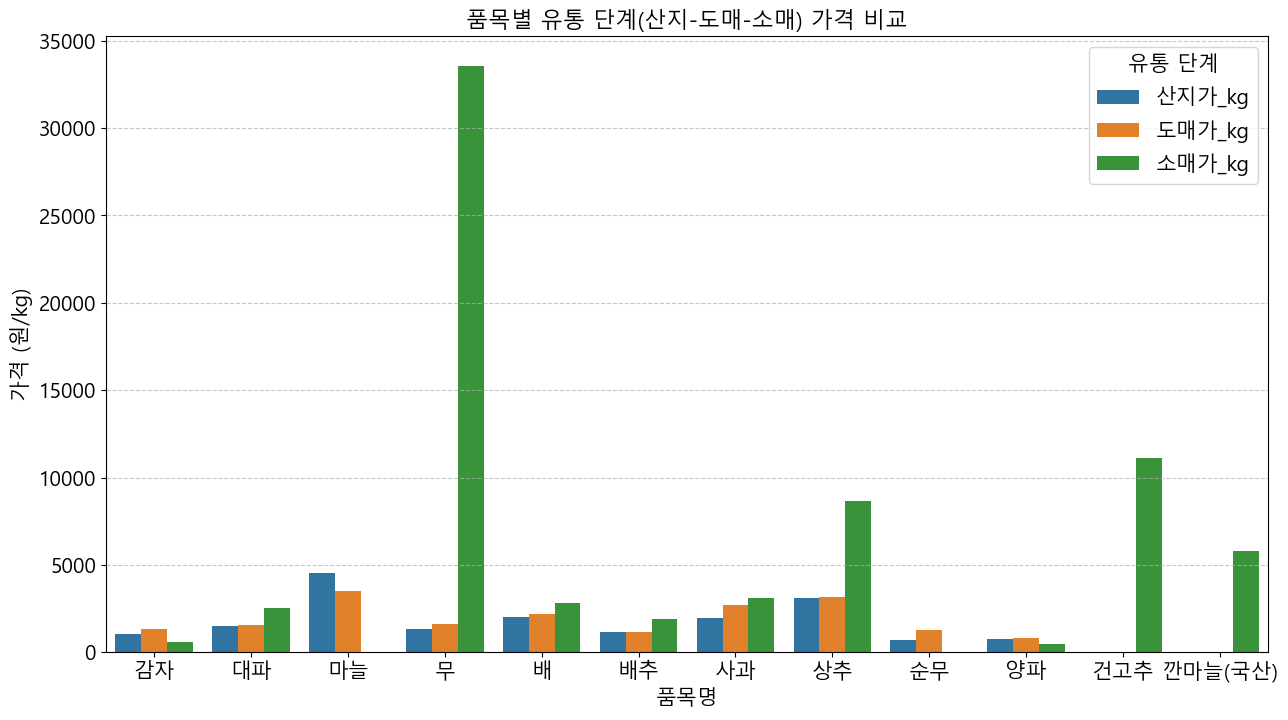

In [58]:
# 1. 산지(os) 평균가 정리
os_avg = df_os.groupby('품목명')['평균가(원/kg)'].mean().rename('산지가_kg')

# 2. 도매(ws) 평균가 정리
ws_avg = df_ws.groupby('품목명')['평균가(원/kg)'].mean().rename('도매가_kg')

# 3. 소매(df) 평균가 정리 (우리가 보정한 가격_per_kg 사용)
retail_avg = df.groupby('품목명')['가격_per_kg'].mean().rename('소매가_kg')

# 4. 전체 합치기
dist_comparison = pd.concat([os_avg, ws_avg, retail_avg], axis=1)

# 유통 비용(마진) 계산: 소매가 - 산지가
dist_comparison['전체마진'] = dist_comparison['소매가_kg'] - dist_comparison['산지가_kg']

display(dist_comparison.sort_values(by='소매가_kg', ascending=False))


import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (아까 만든 dist_comparison 활용)
plot_df = dist_comparison.reset_index()

# 2. 시각화
plt.figure(figsize=(15, 8))
# 넓은 형태(long format)로 변환하여 시각화
melted_df = plot_df.melt(id_vars='품목명', value_vars=['산지가_kg', '도매가_kg', '소매가_kg'])

sns.barplot(data=melted_df, x='품목명', y='value', hue='variable')

plt.title('품목별 유통 단계(산지-도매-소매) 가격 비교', fontsize=16)
plt.ylabel('가격 (원/kg)')
plt.legend(title='유통 단계')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

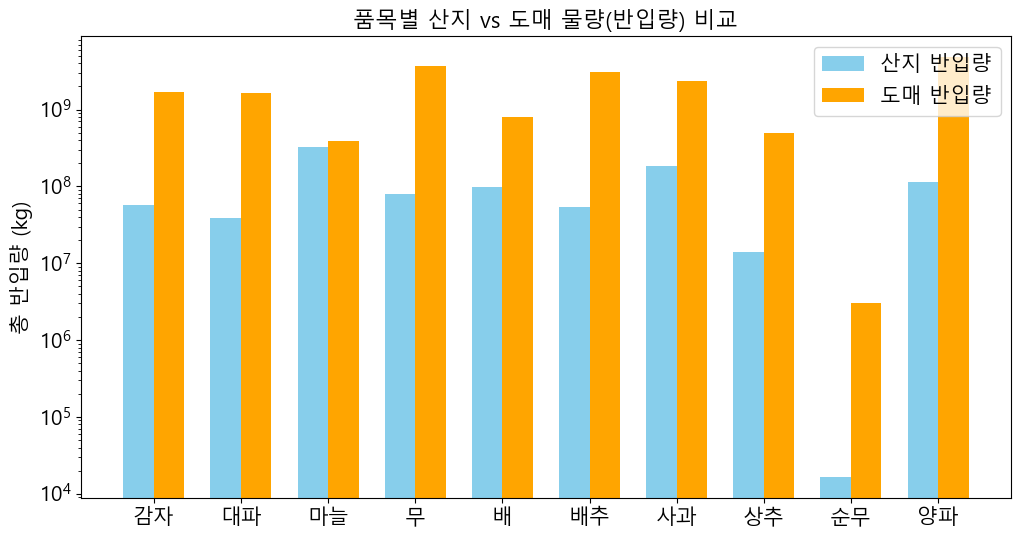

In [59]:
# 아까 계산한 supply_comparison 활용
plt.figure(figsize=(12, 6))

x = range(len(supply_comparison))
width = 0.35

plt.bar([i - width/2 for i in x], supply_comparison['산지_총반입량'], width, label='산지 반입량', color='skyblue')
plt.bar([i + width/2 for i in x], supply_comparison['도매_총반입량'], width, label='도매 반입량', color='orange')

plt.xticks(x, supply_comparison.index)
plt.title('품목별 산지 vs 도매 물량(반입량) 비교', fontsize=16)
plt.ylabel('총 반입량 (kg)')
plt.yscale('log') # 물량 차이가 클 수 있어 로그 스케일 권장
plt.legend()
plt.show()

### 산지 vs 도매 공금량(반입량) 비교

In [54]:
# 산지와 도매의 총반입량 합계 비교
os_supply = df_os.groupby('품목명')['총반입량(kg)'].sum().rename('산지_총반입량')
ws_supply = df_ws.groupby('품목명')['총반입량(kg)'].sum().rename('도매_총반입량')

supply_comparison = pd.concat([os_supply, ws_supply], axis=1)
# 도매 시장 점유 비중 계산
supply_comparison['도매집중도(%)'] = (supply_comparison['도매_총반입량'] / 
                                   (supply_comparison['산지_총반입량'] + supply_comparison['도매_총반입량'])) * 100

display(supply_comparison.sort_values(by='도매_총반입량', ascending=False))

,산지_총반입량,도매_총반입량,도매집중도(%)
품목명,,,
양파,1.146683e+08,4.794167e+09,97.664042
무,8.088781e+07,3.676438e+09,97.847197
배추,5.433517e+07,3.055666e+09,98.252889
사과,1.847354e+08,2.349963e+09,92.711740
감자,5.701486e+07,1.702064e+09,96.758823
대파,3.843634e+07,1.644501e+09,97.716116
배,9.795795e+07,8.081953e+08,89.189693
상추,1.400410e+07,5.016722e+08,97.284323
마늘,3.237621e+08,3.916695e+08,54.745902


### 가격 변동성(위험도) 비교

In [55]:
# 표준편차 / 평균 (변동계수) 계산
os_std = df_os.groupby('품목명')['평균가(원/kg)'].std() / df_os.groupby('품목명')['평균가(원/kg)'].mean()
ws_std = df_ws.groupby('품목명')['평균가(원/kg)'].std() / df_ws.groupby('품목명')['평균가(원/kg)'].mean()
retail_std = df.groupby('품목명')['가격_per_kg'].std() / df.groupby('품목명')['가격_per_kg'].mean()

volatility_comparison = pd.concat([os_std.rename('산지_변동성'), 
                                   ws_std.rename('도매_변동성'), 
                                   retail_std.rename('소매_변동성')], axis=1)

print("--- 가격 변동성 비교 (높을수록 가격 예측이 어려운 품목) ---")
display(volatility_comparison.style.background_gradient(cmap='YlOrRd'))

--- 가격 변동성 비교 (높을수록 가격 예측이 어려운 품목) ---


,산지_변동성,도매_변동성,소매_변동성
품목명,,,
감자,1.417100,0.867612,1.549710
대파,0.770721,0.691821,1.139624
마늘,17.067050,0.706265,nan
무,1.906872,1.769639,5.861388
배,0.563747,0.655684,0.987439
배추,1.353234,1.145010,1.393511
사과,0.626250,5.186948,1.184485
상추,0.907856,0.906759,0.442513
순무,0.669457,2.389627,nan
